<a href="https://colab.research.google.com/github/reginamtxg/M-todos-num-ricos-I/blob/main/MetPuntoFijo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Metodo del Punto Fijo**  
*Regina Garcia Martinez*  
Algoritmo 2.2 (pag 45), Ejemplo 1 (pag 38)

encontrar la solucion de $p=g(p)$ dada una aproximacion inicial $p_0$  
ENTRADA aproximacion inicial $p_0$; tolerancia $TOL$; numero maximo de interaciones $N_0$  
SALIDA aproximada $p$ o mensaje de falla

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Funcion original f(x)
def f(x):
    return x**3 + 4*x**2 - 10

# Funcion g(x) del Ejemplo 1
def g(x):
    return np.sqrt(10.0 / (4.0 + x))

In [35]:
def pfijo(p0, TOL, N0):
    """
    Implementacion del Algoritmo 2.2 del libro
    Parametros:
        p0  : Aproximación inicial
        TOL : Tolerancia
        N0  : Número maximo de iteraciones
    """
    # Paso 1
    i = 1

    lista_i = []
    lista_p = []
    lista_error = []

    # Paso 2
    while i <= N0:
        # Paso 3: Calcular p_i = g(p_{i-1})
        p = g(p0)
        e = np.abs(p - p0)

        # Almacenar valores para la presentacion de resultados
        lista_i.append(i)
        lista_p.append(p)
        lista_error.append(e)

        # Paso 4: Criterio de parada por tolerancia
        if e < TOL:
            print(f"Punto fijo alcanzado en i = {i} iteraciones.")
            print(f"Solución final: p ≈ {p:.9f}")
            return p, lista_i, lista_p, lista_error

        # Paso 5 y 6: Incrementar contador y actualizar p0
        i = i + 1
        p0 = p

    # Paso 7: Mensaje usado en caso de error
    print(f"El método fracasó después de N0 = {N0} iteraciones.")
    return None, lista_i, lista_p, lista_error

In [36]:
# Parametros iniciales
p0 = 1.5
TOL = 1e-5
N0 = 30

# Ejecucion del algoritmo
sol, interaciones, puntos, errores = pfijo(p0, TOL, N0)

# Resultados presentados en una tabla
tabla_resultados = pd.DataFrame({
    'n': iteraciones,
    'p_n': puntos,
    'ε|p_n - p_{n-1}|': errores
}).set_index('n') #para denomimar la columna 'n' como el numero de fila

# Formato numerico (9 decimales)
pd.set_option('display.float_format', lambda x: '%.9f' % x)
display(tabla_resultados)

Punto fijo alcanzado en i = 6 iteraciones.
Solución final: p ≈ 1.365230576


,p_n,ε|p_n - p_{n-1}|
n,,
1,1.348399725,0.151600275
2,1.367376372,0.018976647
3,1.364957015,0.002419357
4,1.365264748,0.000307733
5,1.365225594,0.000039154
6,1.365230576,0.000004982


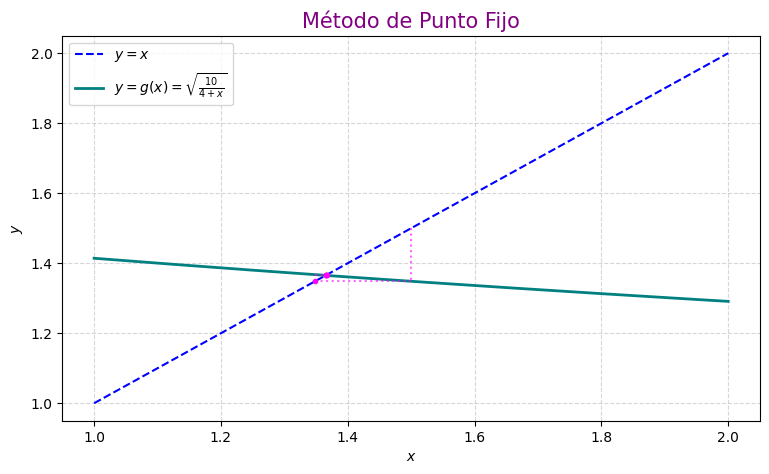

In [37]:
# Grafica de f(x) y la recta y = x junto con g(x)
x_vals = np.linspace(1, 2, 200)

plt.figure(figsize=(9, 5), dpi=100)

# Curvas de referencia
plt.plot(x_vals, x_vals, label=r'$y = x$', color='blue', linestyle='--')
#Grafica con personalizacion de colores
plt.plot(x_vals, g(x_vals), label=r'$y = g(x) = \sqrt{\frac{10}{4+x}}$', color='teal', lw=2)

# Trazado de las iteraciones
p_prev = p0
for p_curr in puntos:
    plt.plot([p_prev, p_prev], [p_prev, p_curr], color='magenta', linestyle=':', alpha=0.6)
    plt.plot([p_prev, p_curr], [p_curr, p_curr], color='magenta', linestyle=':', alpha=0.6)
    plt.plot(p_curr, p_curr, 'o', color='magenta', ms=3)
    p_prev = p_curr

plt.title('Método de Punto Fijo', fontsize=15, color='purple')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()